#Student Performance ML Analysis -->

#Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings("ignore")

#Load DataSet

In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race,parental_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
print(df.columns)

Index(['gender', 'race', 'parental_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')


#Basic Data Exploration

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   gender                   1000 non-null   object
 1   race                     1000 non-null   object
 2   parental_education       1000 non-null   object
 3   lunch                    1000 non-null   object
 4   test_preparation_course  1000 non-null   object
 5   math_score               1000 non-null   int64 
 6   reading_score            1000 non-null   int64 
 7   writing_score            1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


gender                     0
race                       0
parental_education         0
lunch                      0
test_preparation_course    0
math_score                 0
reading_score              0
writing_score              0
dtype: int64

#Feature Engineering

In [5]:
df['Total_Score'] = df['math_score'] + df['reading_score'] + df['writing_score']

def categorize(score):
    if score < 150:
        return 'Low'
    elif score < 250:
        return 'Medium'
    else:
        return 'High'

df['Performance'] = df['Total_Score'].apply(categorize)
df['Performance'].value_counts()

Medium    758
High      139
Low       103
Name: Performance, dtype: int64

#Data Visualization Section

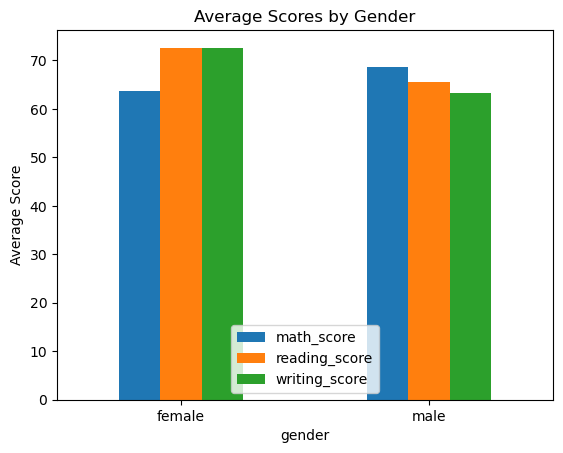

In [6]:
df.groupby('gender')[['math_score','reading_score','writing_score']].mean().plot(kind='bar')
plt.title("Average Scores by Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.show()

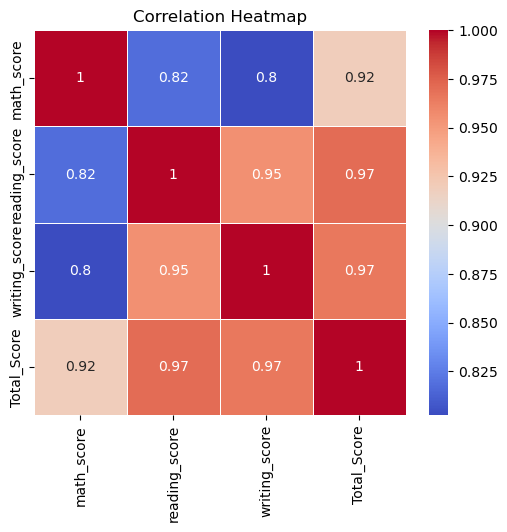

In [7]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[['math_score','reading_score','writing_score','Total_Score']].corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

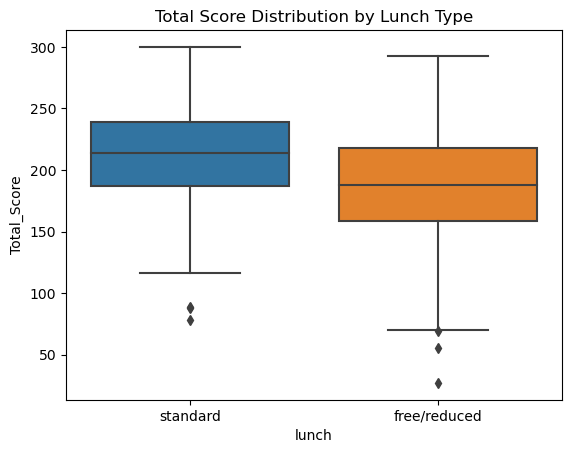

In [8]:
plt.figure()
sns.boxplot(x='lunch', y='Total_Score', data=df)
plt.title("Total Score Distribution by Lunch Type")
plt.show()

In [9]:
le = LabelEncoder()

categorical_cols = ['gender', 'race',
                    'parental_education',
                    'lunch', 'test_preparation_course',
                    'Performance']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [10]:
X = df[['gender', 'race', 'parental_education',
        'lunch', 'test_preparation_course']]
y = df['Performance']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Logistic Regression

In [13]:
log_model = LogisticRegression(class_weight='balanced')


log_model.fit(X_train, y_train)


y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.31
              precision    recall  f1-score   support

           0       0.21      0.61      0.31        28
           1       0.18      0.70      0.28        20
           2       0.79      0.20      0.32       152

    accuracy                           0.31       200
   macro avg       0.39      0.50      0.31       200
weighted avg       0.65      0.31      0.32       200



#Random Forest

In [14]:
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.51
              precision    recall  f1-score   support

           0       0.23      0.36      0.28        28
           1       0.12      0.25      0.16        20
           2       0.76      0.57      0.65       152

    accuracy                           0.51       200
   macro avg       0.37      0.39      0.36       200
weighted avg       0.62      0.51      0.55       200



In [ ]:
#KNN

In [15]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.71
              precision    recall  f1-score   support

           0       0.18      0.07      0.10        28
           1       0.29      0.10      0.15        20
           2       0.76      0.91      0.83       152

    accuracy                           0.71       200
   macro avg       0.41      0.36      0.36       200
weighted avg       0.63      0.71      0.66       200



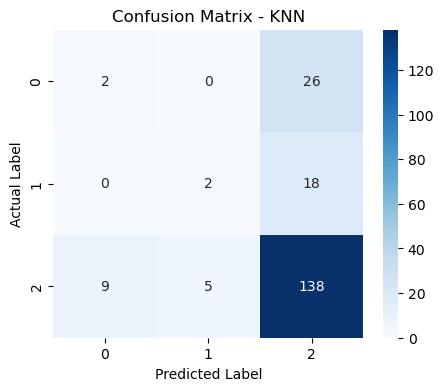

In [16]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [17]:
models = {
    "Logistic": LogisticRegression(class_weight='balanced'),
    "RandomForest": RandomForestClassifier(class_weight='balanced'),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(name, "Average CV Score:", scores.mean())

Logistic Average CV Score: 0.373
RandomForest Average CV Score: 0.508
KNN Average CV Score: 0.6839999999999999


In [18]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': 20, 'n_estimators': 200}
Best Score: 0.70625


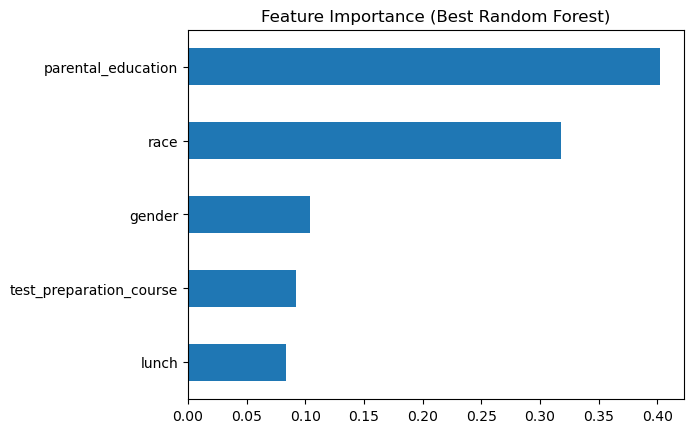

In [19]:
best_rf = grid.best_estimator_

feature_importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
)

feature_importances.sort_values().plot(kind='barh')
plt.title("Feature Importance (Best Random Forest)")
plt.show()